In [67]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)###

In [68]:
setwd("./02metabolism_replot/")

In [69]:
meta <- read.csv("C_vs_R_up.csv",check.names = FALSE,row.names = 1)
meta$log10P <- -log10(meta$`Raw p`)
meta$'Enrichment Ratio' <- c(meta$hits/meta$total)/c(19/sum(meta$total))
write.csv(meta,"C_vs_R_up_enrich_ratio.csv")
meta1 <- meta[which(meta$`Raw p`<0.05),]
meta2 <- meta1[which(meta1$log10P>1.4),]
meta2$pathway <- rownames(meta2)
meta2$pathway <- factor(meta2$pathway,levels =rev(rownames(meta2) ))

In [70]:
plotdata <- meta2

In [71]:
plotdata$adjustp.bh <- p.adjust(plotdata$`Raw p`,method = "BH")

In [72]:
plotdata$Signif <- " "
plotdata[which(plotdata$`adjustp.bh`>=0.01&plotdata$`adjustp.bh`<0.05),]$Signif <- "*"
plotdata[which(plotdata$`adjustp.bh`>=0.001&plotdata$`adjustp.bh`<0.01),]$Signif <- "**"
# plotdata[which(plotdata$`adjustp.bh`>=0.0001&plotdata$`adjustp.bh`<0.001),]$Signif <- "***"
plotdata

,total,expected,hits,Raw p,Holm p,FDR,log10P,Enrichment Ratio,pathway,adjustp.bh,Signif
,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<chr>
Sphingolipid metabolism: integrated pathway,49,0.13700,3,0.000288,0.956,0.956,3.540608,20.371643,Sphingolipid metabolism: integrated pathway,0.00460800,**
Growth factors and hormones in Beta-cell proliferation,3,0.00841,1,0.008390,1.000,1.000,2.076238,110.912281,Growth factors and hormones in Beta-cell proliferation,0.03584000,*
"Role of hypoxia, angiogenesis, and FGF pathway in OA chondrocyte hypertrophy",3,0.00841,1,0.008390,1.000,1.000,2.076238,110.912281,"Role of hypoxia, angiogenesis, and FGF pathway in OA chondrocyte hypertrophy",0.03584000,*
Endochondral ossification with skeletal dysplasias,4,0.01120,1,0.011200,1.000,1.000,1.950782,83.184211,Endochondral ossification with skeletal dysplasias,0.03584000,*
Endochondral ossification,4,0.01120,1,0.011200,1.000,1.000,1.950782,83.184211,Endochondral ossification,0.03584000,*
Regulation of thyroid hormone activity,5,0.01400,1,0.013900,1.000,1.000,1.856985,66.547368,Regulation of thyroid hormone activity,0.03706667,*
Diclofenac metabolic pathway,6,0.01680,1,0.016700,1.000,1.000,1.777284,55.456140,Diclofenac metabolic pathway,0.03817143,*
Hippocampal synaptogenesis and neurogenesis,7,0.01960,1,0.019500,1.000,1.000,1.709965,47.533835,Hippocampal synaptogenesis and neurogenesis,0.03860000,*
Glucose metabolism in triple-negative breast cancer cells,9,0.02520,1,0.025000,1.000,1.000,1.602060,36.970760,Glucose metabolism in triple-negative breast cancer cells,0.03860000,*


In [73]:
plotdata <- plotdata[1:10,]

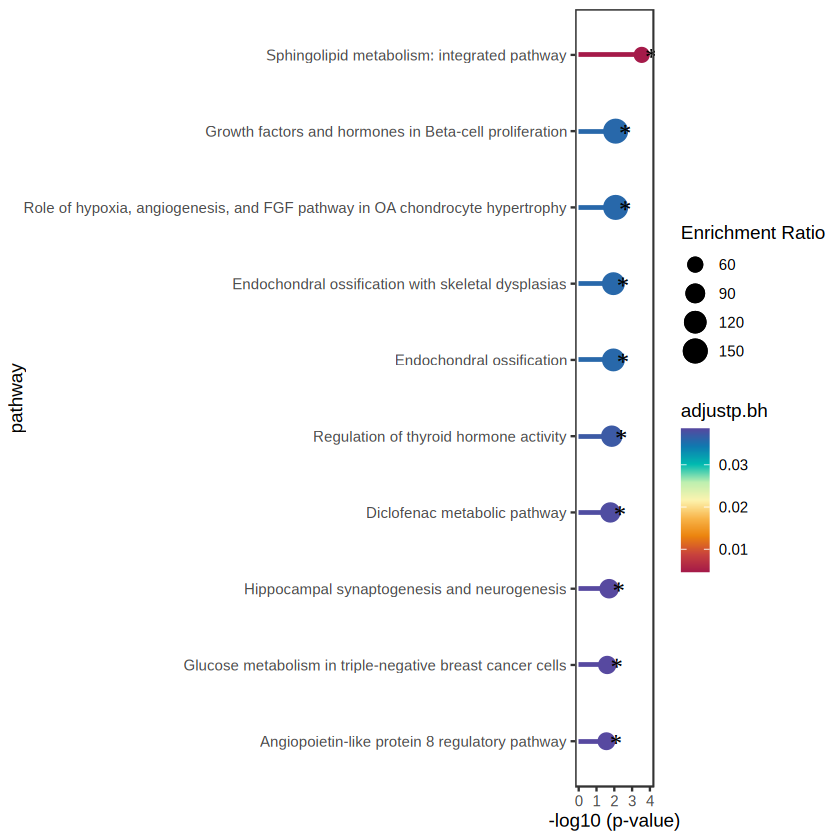

pdf 
  2

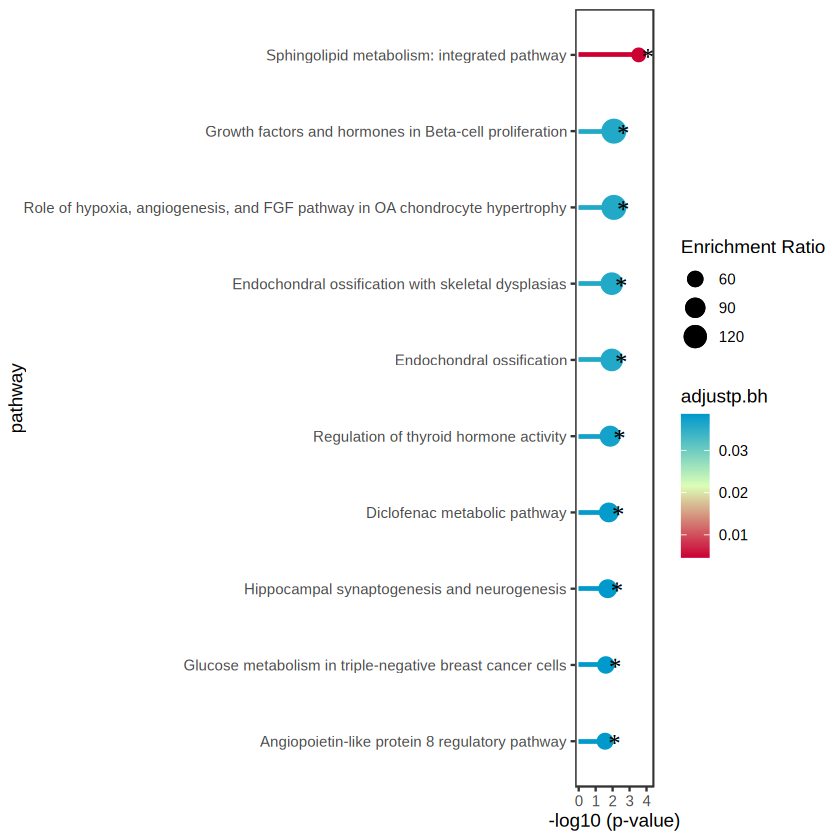

In [105]:
p1 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("adjustp.bh")), linewidth = 1, show.legend = F) + #
  geom_point(aes(x = log10P, y = pathway, color=get("adjustp.bh"),size = get('Enrichment Ratio')+40)) + # 
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio')+10),  shape = 21, fill = NA)+theme_bw()+labs(color="adjustp.bh",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.2 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c('#5749a0', '#0f7ab0', '#00bbb1',
                                    '#bef0b0', '#fdf4af', '#f9b64b',
                                    '#ec840e', '#ca443d', '#a51a49')))(100))+
xlim(0, 4)
p2 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("adjustp.bh")), linewidth = 1, show.legend = F) + # 
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio')+30)) + # 
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio')+10),  shape = 21, fill = NA)+theme_bw()+labs(color="adjustp.bh",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.2 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c("#0099CC", "#DCFFB7", "#CC0033")))(100))+
xlim(0, 4.2)
p1
p2
pdf("C_vs_R_up_enrich_ratio.pdf",width = 9,height = 5)
print(p1)
print(p2)
dev.off()

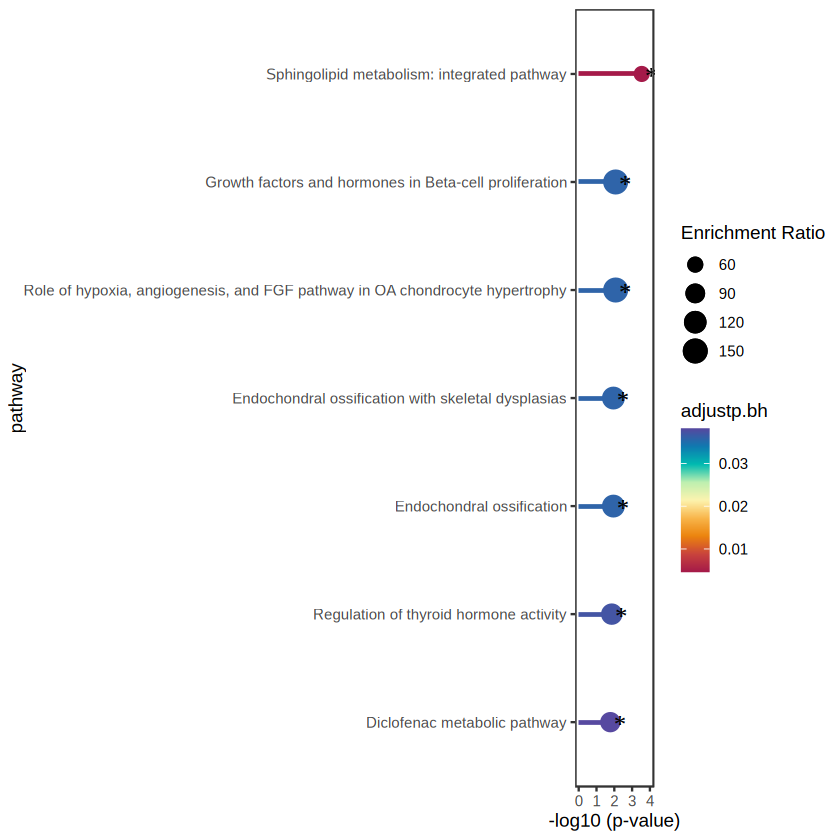

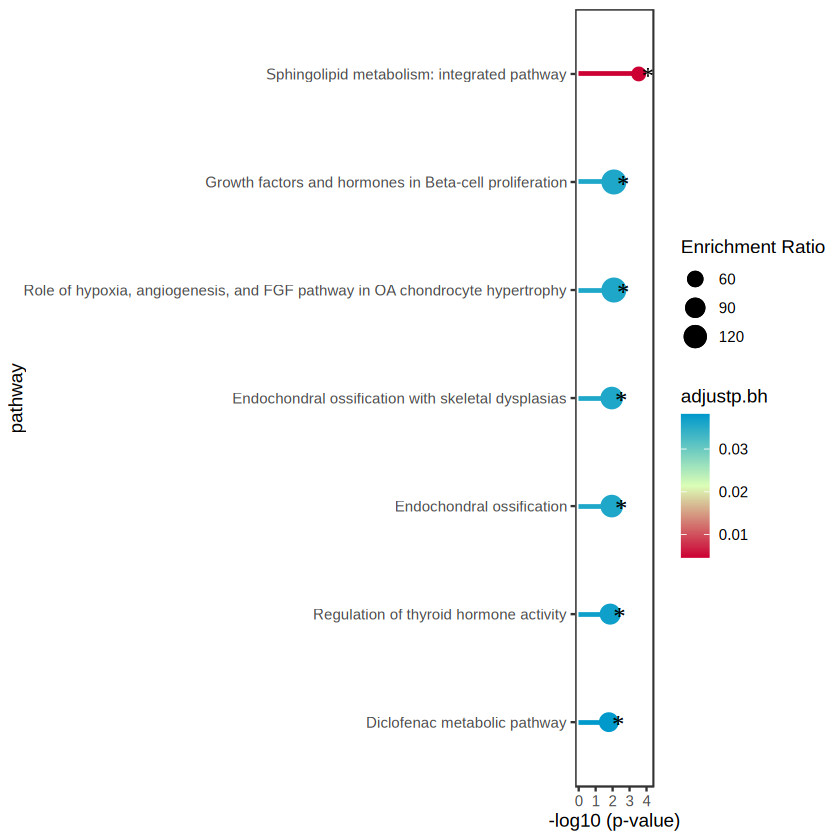

In [54]:
plotdata <- plotdata[1:7,]
p1 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("adjustp.bh")), linewidth = 1, show.legend = F) + 
  geom_point(aes(x = log10P, y = pathway, color=get("adjustp.bh"),size = get('Enrichment Ratio')+40)) + 
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio')+10),  shape = 21, fill = NA)+theme_bw()+labs(color="adjustp.bh",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.2 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c('#5749a0', '#0f7ab0', '#00bbb1',
                                    '#bef0b0', '#fdf4af', '#f9b64b',
                                    '#ec840e', '#ca443d', '#a51a49')))(100))+
xlim(0, 4)
p2 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("adjustp.bh")), linewidth = 1, show.legend = F) + 
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio')+30)) + # 绘制棒棒糖的糖中心圆
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio')+10),  shape = 21, fill = NA)+theme_bw()+labs(color="adjustp.bh",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.2 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c("#0099CC", "#DCFFB7", "#CC0033")))(100))+
xlim(0, 4.2)
p1
p2

In [106]:
meta <- read.csv("C_R_down.csv",check.names = FALSE,row.names = 1)
meta$log10P <- -log10(meta$`Raw p`)
meta$'Enrichment Ratio' <- c(meta$hits/meta$total)/c(15/sum(meta$total))
write.csv(meta,"C_R_down_enrich_ratio.csv")
meta1 <- meta[which(meta$`Raw p`<0.05),]
meta2 <- meta1[which(meta1$log10P>1.55),]
meta2$pathway <- rownames(meta2)
meta2$pathway <- factor(meta2$pathway,levels =rev(rownames(meta2) ))

In [107]:
meta2

,total,expected,hits,Raw p,Holm p,FDR,log10P,Enrichment Ratio,pathway
,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<fct>
Degradation of cysteine and homocysteine,37,0.06910,2,0.00197,1,1,2.705534,45.57117,Degradation of cysteine and homocysteine
Membrane binding and targetting of GAG proteins,2,0.00374,1,0.00373,1,1,2.428291,421.53333,Membrane binding and targetting of GAG proteins
"Synthesis And Processing Of GAG, GAGPOL Polyproteins",2,0.00374,1,0.00373,1,1,2.428291,421.53333,"Synthesis And Processing Of GAG, GAGPOL Polyproteins"
"Trans-sulfuration, one-carbon metabolism and related pathways",58,0.10800,2,0.00479,1,1,2.319664,29.07126,"Trans-sulfuration, one-carbon metabolism and related pathways"
Assembly Of The HIV Virion,3,0.00561,1,0.00560,1,1,2.251812,281.02222,Assembly Of The HIV Virion
Visual phototransduction,64,0.12000,2,0.00581,1,1,2.235824,26.34583,Visual phototransduction
Sulfur amino acid metabolism,65,0.12100,2,0.00599,1,1,2.222573,25.94051,Sulfur amino acid metabolism
Metal sequestration by antimicrobial proteins,7,0.01310,1,0.01300,1,1,1.886057,120.43810,Metal sequestration by antimicrobial proteins
"Biosynthesis of A2E, implicated in retinal degradation",7,0.01310,1,0.01300,1,1,1.886057,120.43810,"Biosynthesis of A2E, implicated in retinal degradation"


In [144]:
plotdata <- meta2
plotdata$adjustp.bh <- p.adjust(plotdata$`Raw p`,method = "BH")

In [145]:
plotdata$Signif <- " "
plotdata[which(plotdata$`adjustp.bh`>=0.01&plotdata$`adjustp.bh`<0.05),]$Signif <- "*"
# plotdata[which(plotdata$`adjustp.bh`>=0.001&plotdata$`adjustp.bh`<0.01),]$Signif <- "**"
plotdata

,total,expected,hits,Raw p,Holm p,FDR,log10P,Enrichment Ratio,pathway,adjustp.bh,Signif
,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<fct>,<dbl>,<chr>
Degradation of cysteine and homocysteine,37,0.06910,2,0.00197,1,1,2.705534,45.57117,Degradation of cysteine and homocysteine,0.02053714,*
Membrane binding and targetting of GAG proteins,2,0.00374,1,0.00373,1,1,2.428291,421.53333,Membrane binding and targetting of GAG proteins,0.02053714,*
"Synthesis And Processing Of GAG, GAGPOL Polyproteins",2,0.00374,1,0.00373,1,1,2.428291,421.53333,"Synthesis And Processing Of GAG, GAGPOL Polyproteins",0.02053714,*
"Trans-sulfuration, one-carbon metabolism and related pathways",58,0.10800,2,0.00479,1,1,2.319664,29.07126,"Trans-sulfuration, one-carbon metabolism and related pathways",0.02053714,*
Assembly Of The HIV Virion,3,0.00561,1,0.00560,1,1,2.251812,281.02222,Assembly Of The HIV Virion,0.02053714,*
Visual phototransduction,64,0.12000,2,0.00581,1,1,2.235824,26.34583,Visual phototransduction,0.02053714,*
Sulfur amino acid metabolism,65,0.12100,2,0.00599,1,1,2.222573,25.94051,Sulfur amino acid metabolism,0.02053714,*
Metal sequestration by antimicrobial proteins,7,0.01310,1,0.01300,1,1,1.886057,120.43810,Metal sequestration by antimicrobial proteins,0.02702609,*
"Biosynthesis of A2E, implicated in retinal degradation",7,0.01310,1,0.01300,1,1,1.886057,120.43810,"Biosynthesis of A2E, implicated in retinal degradation",0.02702609,*


In [146]:
plotdata <- plotdata[1:10,]

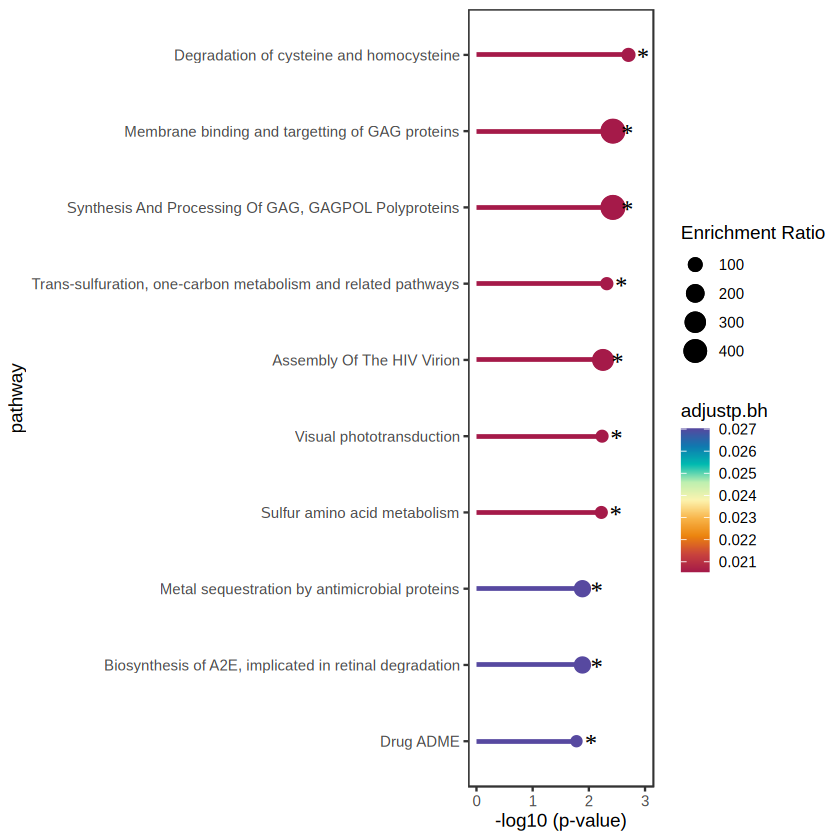

pdf 
  2

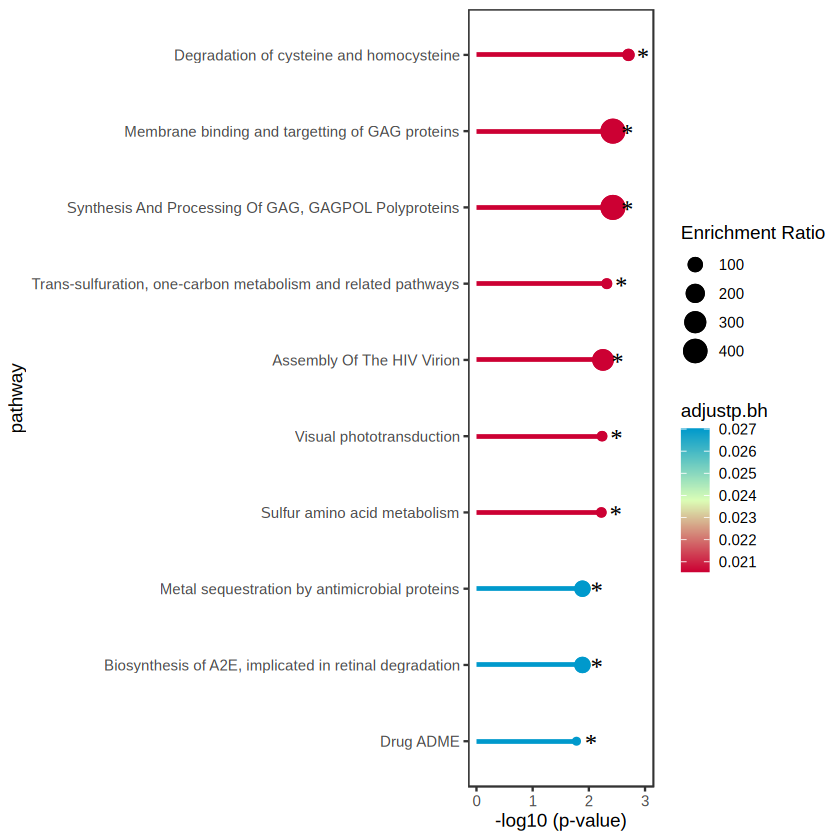

In [147]:
p1 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("adjustp.bh")), linewidth = 1, show.legend = F) + # 绘制棒棒糖的棒
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio')+40)) + # 绘制棒棒糖的糖中心圆
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio')+4),  shape = 21, fill = NA)+theme_bw()+labs(color="adjustp.bh",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.15 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c('#5749a0', '#0f7ab0', '#00bbb1',
                                    '#bef0b0', '#fdf4af', '#f9b64b',
                                    '#ec840e', '#ca443d', '#a51a49')))(100))+
xlim(0, 3)
p2 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("adjustp.bh")), linewidth = 1, show.legend = F) + 
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio'))) + 
  geom_point(aes(x = log10P, y = pathway,  color=get("adjustp.bh"),size = get('Enrichment Ratio')+4),  shape = 21, fill = NA)+theme_bw()+labs(color="adjustp.bh",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.15 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c("#0099CC", "#DCFFB7", "#CC0033")))(100))+
xlim(0, 3)
p1
p2
pdf("C_vs_R_down_enrich_ratio.pdf",width = 9,height = 7)
print(p1)
print(p2)
dev.off()

In [20]:
meta <- read.csv("TR_R_up.csv",check.names = FALSE,row.names = 1)
meta$log10P <- -log10(meta$`Raw p`)
meta$'Enrichment Ratio' <- c(meta$hits/meta$total)/c(42/sum(meta$total))
write.csv(meta,"TR_R_up_enrich_ratio.csv")
meta1 <- meta[which(meta$`Raw p`<0.05),]
meta2 <- meta1[which(meta1$log10P>2.58),]
meta2$pathway <- rownames(meta2)
meta2$pathway <- factor(meta2$pathway,levels =rev(rownames(meta2) ))

In [31]:
plotdata <- meta
plotdata$Signif <- " "
plotdata[which(plotdata$`Raw p`>=0.01&plotdata$`Raw p`<0.05),]$Signif <- "*"
plotdata[which(plotdata$`Raw p`>=0.001&plotdata$`Raw p`<0.01),]$Signif <- "**"
plotdata[which(plotdata$`Raw p`>=0.0001&plotdata$`Raw p`<0.001),]$Signif <- "***"
plotdata[which(plotdata$`Raw p`<0.0001),]$Signif <- "****"
plotdata <- plotdata[which(plotdata$log10P>2.56),]

In [32]:
plotdata$pathway <- rownames(plotdata)
plotdata$pathway <- factor(plotdata$pathway,levels =rev(rownames(plotdata)))

In [33]:
plotdata <- plotdata[3:12,]

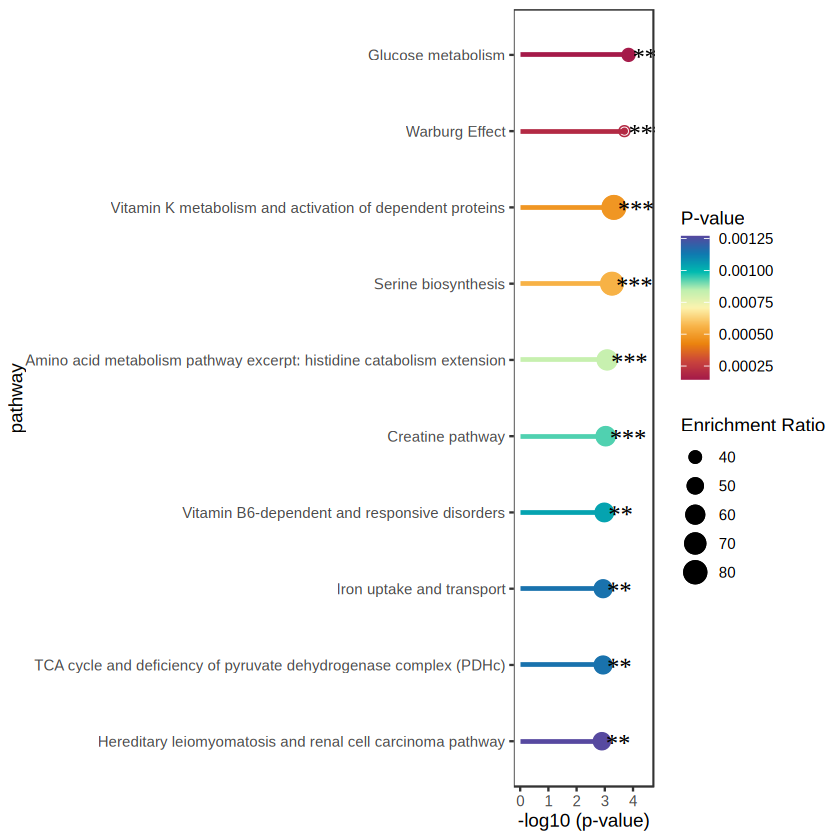

pdf 
  2

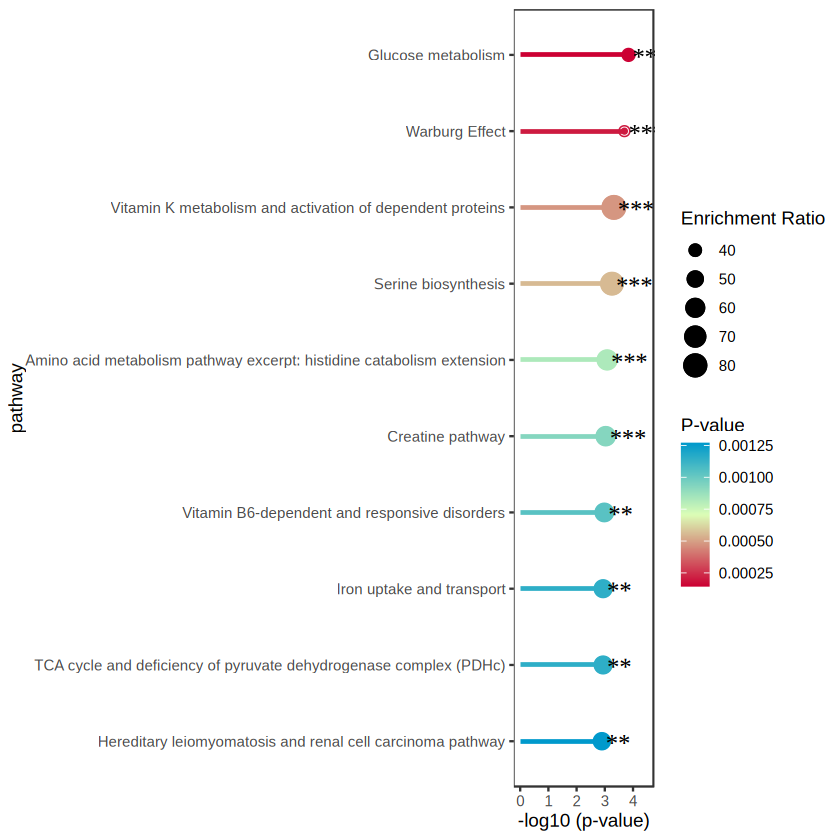

In [37]:
p1 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("Raw p")), linewidth = 1, show.legend = F) +
  geom_point(aes(x = log10P, y = pathway,  color=get("Raw p"),size = get('Enrichment Ratio'))) + 
  geom_point(aes(x = log10P, y = pathway,  color=get("Raw p"),size = get('Enrichment Ratio')+4),  shape = 21, fill = NA)+theme_bw()+labs(color="P-value",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.15 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c('#5749a0', '#0f7ab0', '#00bbb1',
                                    '#bef0b0', '#fdf4af', '#f9b64b',
                                    '#ec840e', '#ca443d', '#a51a49')))(100))+
xlim(0, 4.5)
p2 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("Raw p")), linewidth = 1, show.legend = F) +
  geom_point(aes(x = log10P, y = pathway,  color=get("Raw p"),size = get('Enrichment Ratio'))) + 
  geom_point(aes(x = log10P, y = pathway,  color=get("Raw p"),size = get('Enrichment Ratio')+4),  shape = 21, fill = NA)+theme_bw()+labs(color="P-value",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.15 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c("#0099CC", "#DCFFB7", "#CC0033")))(100))+
xlim(0, 4.5)
p1
p2
pdf("TR_R_up_enrich_ratio.pdf",width = 9,height = 5)
print(p1)
print(p2)
dev.off()

In [38]:
plotdata <- plotdata[1:7,]

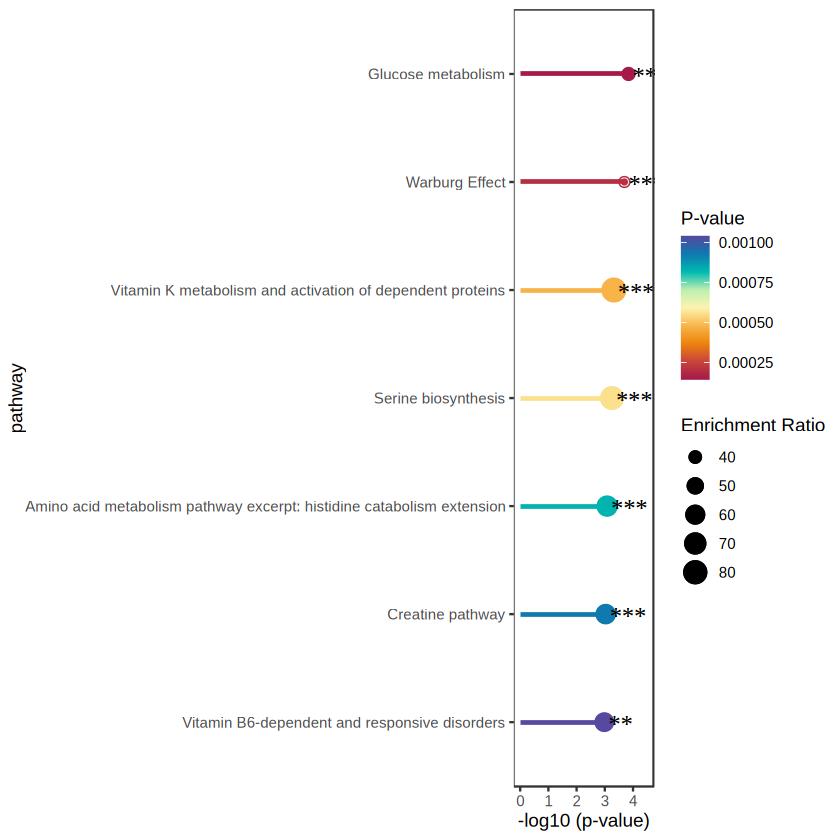

pdf 
  2

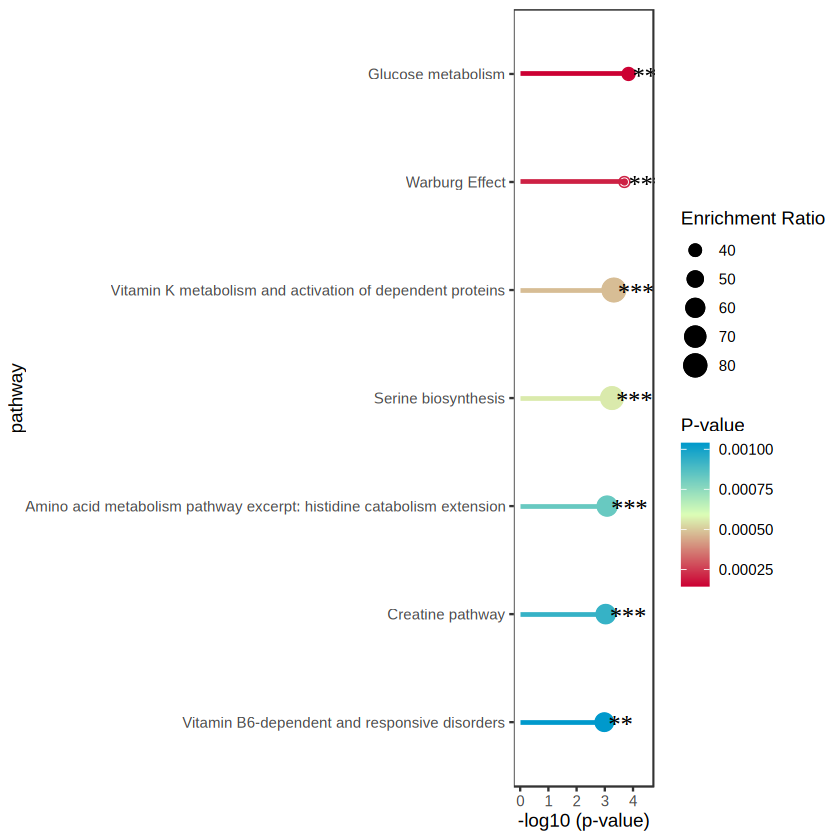

In [39]:
p1 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("Raw p")), linewidth = 1, show.legend = F) + 
  geom_point(aes(x = log10P, y = pathway,  color=get("Raw p"),size = get('Enrichment Ratio'))) + 
  geom_point(aes(x = log10P, y = pathway,  color=get("Raw p"),size = get('Enrichment Ratio')+4),  shape = 21, fill = NA)+theme_bw()+labs(color="P-value",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.15 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c('#5749a0', '#0f7ab0', '#00bbb1',
                                    '#bef0b0', '#fdf4af', '#f9b64b',
                                    '#ec840e', '#ca443d', '#a51a49')))(100))+
xlim(0, 4.5)
p2 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = log10P, y = pathway, yend = pathway,color=get("Raw p")), linewidth = 1, show.legend = F) + 
  geom_point(aes(x = log10P, y = pathway,  color=get("Raw p"),size = get('Enrichment Ratio'))) +
  geom_point(aes(x = log10P, y = pathway,  color=get("Raw p"),size = get('Enrichment Ratio')+4),  shape = 21, fill = NA)+theme_bw()+labs(color="P-value",size="Enrichment Ratio",x="-log10 (p-value)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = log10P + 0.15 , y = pathway, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c("#0099CC", "#DCFFB7", "#CC0033")))(100))+
xlim(0, 4.5)
p1
p2
pdf("TR_R_up_enrich_ratio1.pdf",width = 9,height = 5)
print(p1)
print(p2)
dev.off()

In [2]:

library(ggplot2)
library(dplyr)
library(tidyr)
library(cluster)


Attaching package: ‘cluster’


The following object is masked from ‘package:spatstat.geom’:

    volume




In [4]:
setwd("./03kmeans_linePlot/")

In [139]:
exp <- read.csv("all_sample_mt.csv",check.names = FALSE)
rownames(exp) <- exp$Compounds
colnames(exp)

[1] "Compounds"   "C"           "C-GCLINL"    "C-ONL"       "C-RPE"      
 [6] "C-Cretina"   "R"           "R-GCLINL"    "R-ONL"       "R-RPE"      
[11] "R-Rretina"   "T"           "T-GCLINL"    "T-ONL"       "T-RPE"      
[16] "T-Tretina"   "TR"          "TR-GCLINL"   "TR-ONL"      "TR-RPE"     
[21] "TR-TRretina"

In [140]:
exp1 <- subset(exp,select=c("C-GCLINL","R-GCLINL","T-GCLINL","TR-GCLINL"))

In [141]:
exp2 <- as.data.frame(t(scale(t(exp1))))

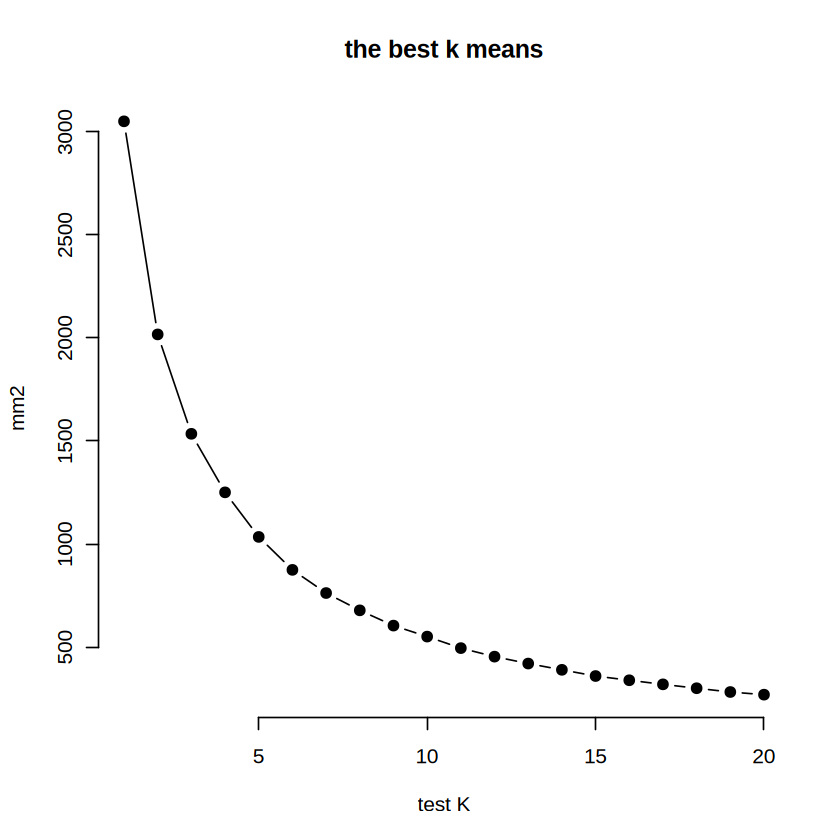

In [142]:
# 方法1：肘部法则
wss <- sapply(1:20, function(k){
  kmeans(exp2, centers=k, nstart=25)$tot.withinss
})

plot(1:20, wss, type="b", pch=19, frame=FALSE, 
     xlab="test K", ylab="mm2",
     main="the best k means")

In [143]:

k <- 20

set.seed(123)
kmeans_result <- kmeans(exp2, centers=k, nstart=25)

table(kmeans_result$cluster)

cluster_labels <- kmeans_result$cluster


  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
 42  46  64  76  56  57  74  75  38  48  65  74 110  74  35  37  66  43  29  63 

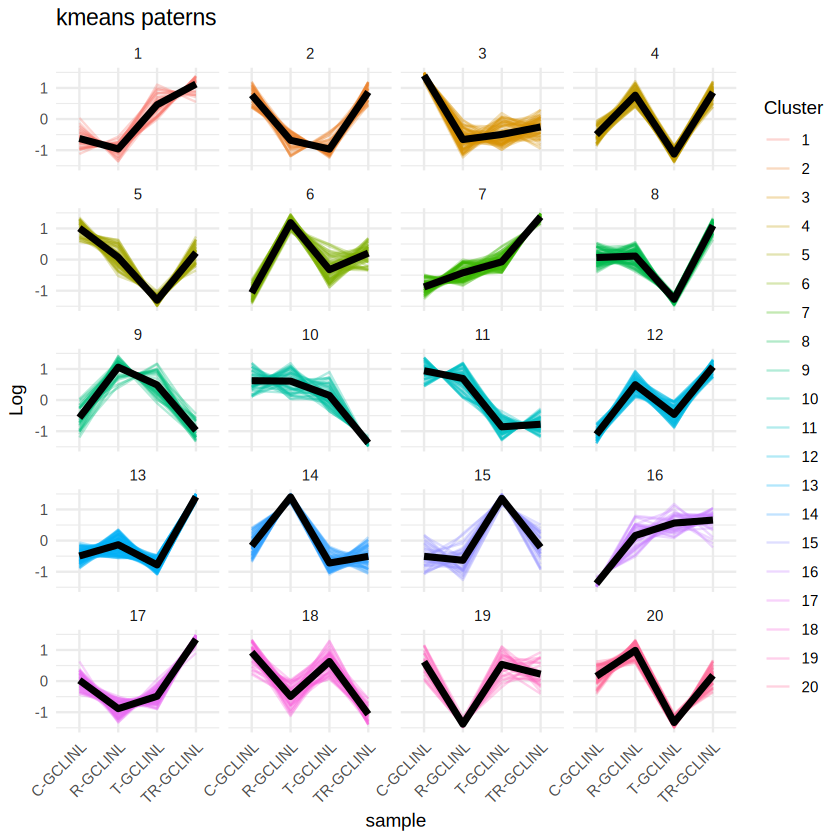

In [148]:

plot_data <- as.data.frame(exp2) %>%
  mutate(Gene = rownames(exp2),
         Cluster = as.factor(cluster_labels)) %>%
  pivot_longer(cols = -c(Gene, Cluster), 
               names_to = "Sample", 
               values_to = "Expression")
ggplot(plot_data, aes(x = Sample, y = Expression, group = Gene)) +
  geom_line(alpha = 0.3, aes(color = Cluster)) +
  facet_wrap(~ Cluster, ncol = 4) +
  stat_summary(aes(group = Cluster), fun = mean, geom = "line", 
               size = 1.5, color = "black") +
  labs(title = "kmeans paterns",
       x = "sample",
       y = "Log") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
ggsave("4group_cluster.pdf",width = 16,height = 15)

In [149]:
write.csv(plot_data,"kmeans_cluster.csv")

In [176]:
m <- plot_data
m$group <- "NA"

In [177]:
m[which(m$Cluster%in%c("2","17")),]$group <- "Pattern A"
m[which(m$Cluster%in%c("9")),]$group <- "Pattern B"
m[which(m$Cluster%in%c("4","6","12","20")),]$group <- "Pattern C"

In [178]:
mer <- m[which(m$group!="NA"),]

In [179]:
table(mer$group)


Pattern A Pattern B Pattern C 
      448       152      1080 

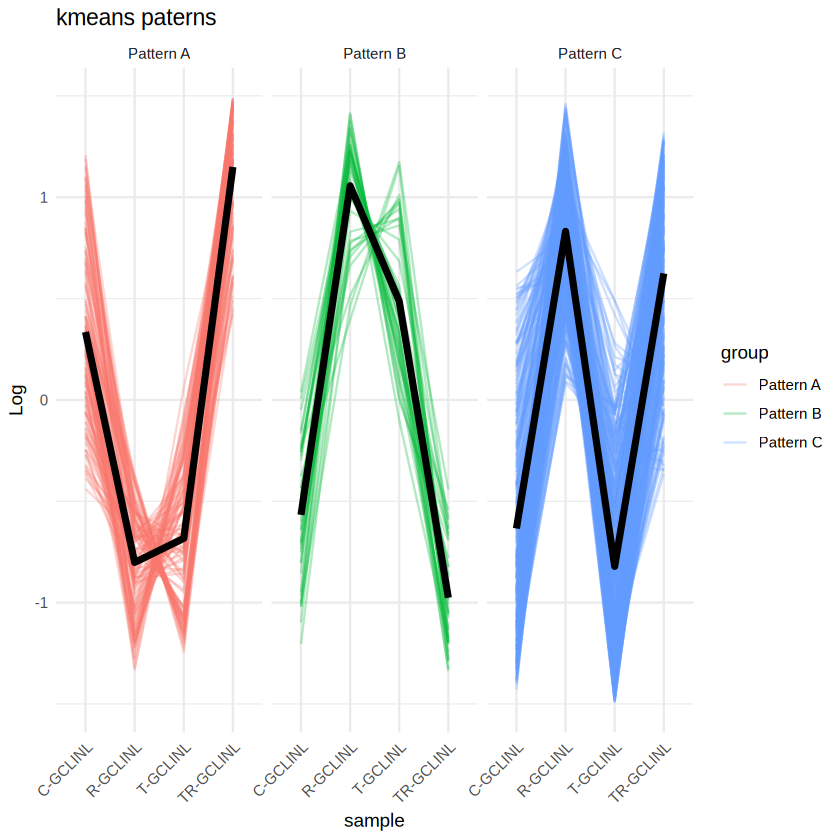

In [180]:
ggplot(mer, aes(x = Sample, y = Expression, group = Gene)) +
  geom_line(alpha = 0.3, aes(color = group)) +
  facet_wrap(~ group, ncol = 4) +
  stat_summary(aes(group = group), fun = mean, geom = "line", 
               size = 1.5, color = "black") +
  labs(title = "kmeans paterns",
       x = "sample",
       y = "Log") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
ggsave("test.pdf",width = 18,height = 6)

In [219]:
m1 <- mer[which(mer$group=="Pattern A"),]

In [220]:
cols1 <- c('Blank2'="#2b6a99",'Blank1'="#6BAED6",'RIR1'="#FAA419",'RIR2'="#f16c23")

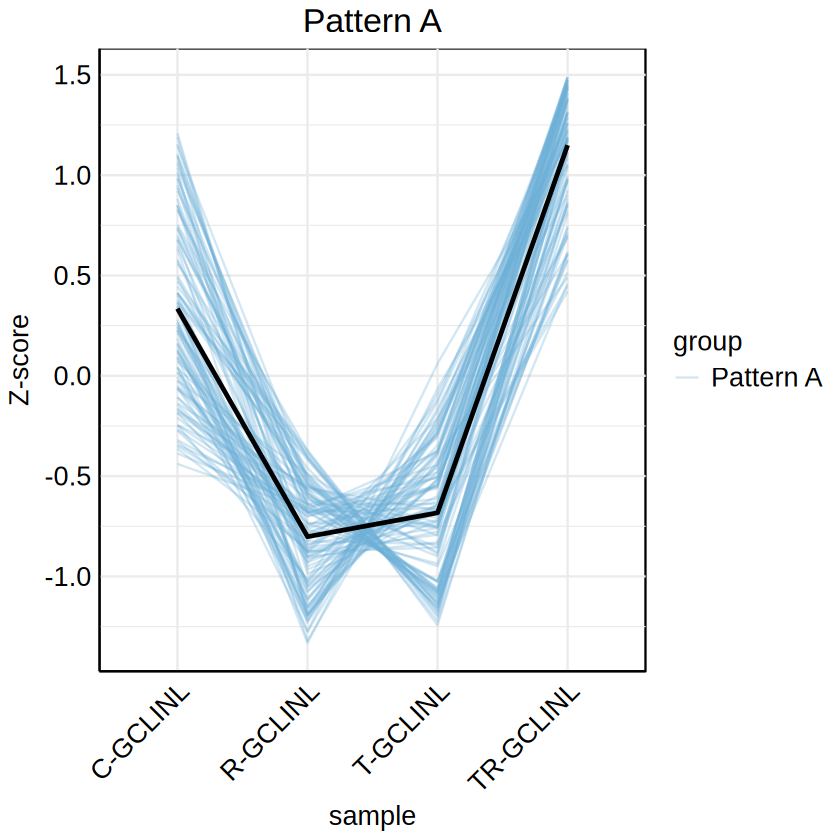

In [221]:
ggplot(m1, aes(x = Sample, y = Expression, group = Gene)) +
  geom_line(alpha = 0.3, siz=0.3,aes(color = group)) +
  stat_summary(aes(group = group), fun = mean, geom = "line", 
               size = 1, color = "black") +
  labs(title = "Pattern A",
       x = "sample",
       y = "Z-score") +
  theme_minimal() +scale_color_manual(values = "#6BAED6")+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title= element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'),
    axis.line.x = element_line (color = 'black',linetype = 'solid'), 
    panel.background=element_rect(fill="white"))
ggsave("PatternsA.pdf",width = 8,height = 6)

In [222]:
m1 <- mer[which(mer$group=="Pattern B"),]

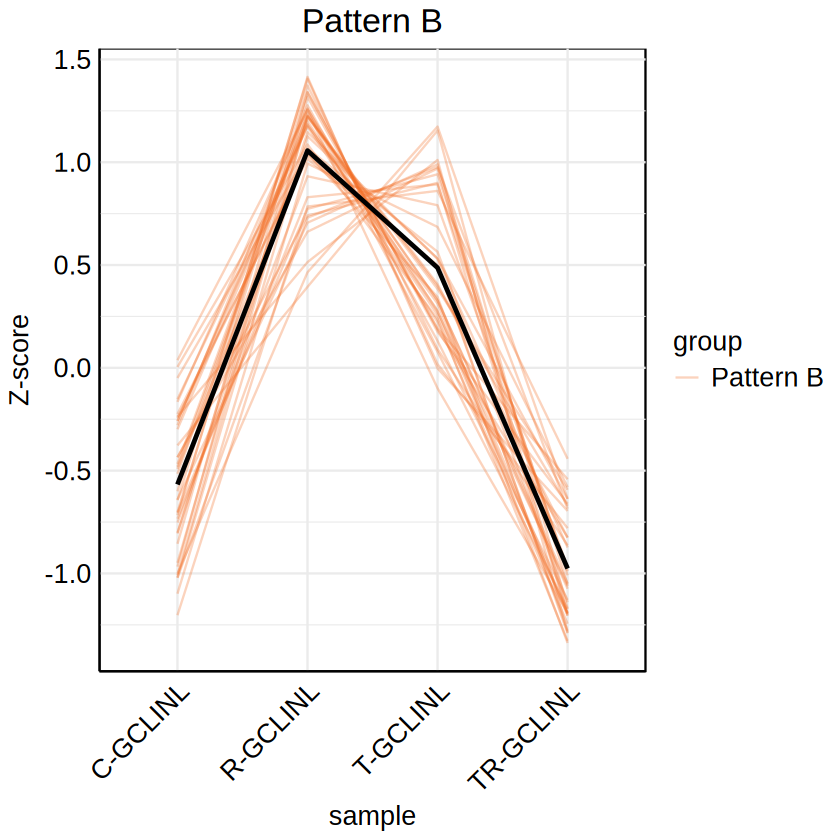

In [223]:
ggplot(m1, aes(x = Sample, y = Expression, group = Gene)) +
  geom_line(alpha = 0.3, siz=0.3,aes(color = group)) +
  stat_summary(aes(group = group), fun = mean, geom = "line", 
               size = 1, color = "black") +
  labs(title = "Pattern B",
       x = "sample",
       y = "Z-score") +
  theme_minimal() +scale_color_manual(values = "#f16c23")+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title= element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'),
    axis.line.x = element_line (color = 'black',linetype = 'solid'), 
    panel.background=element_rect(fill="white"))
ggsave("PatternsB.pdf",width = 8,height = 6)

In [224]:
m1 <- mer[which(mer$group=="Pattern C"),]

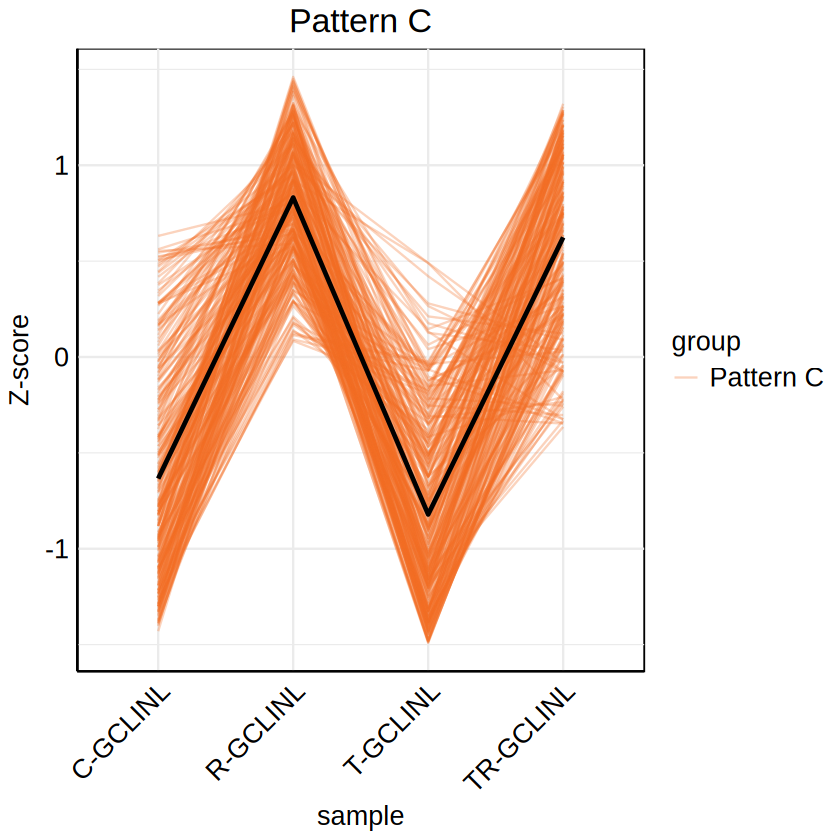

In [225]:
ggplot(m1, aes(x = Sample, y = Expression, group = Gene)) +
  geom_line(alpha = 0.3, siz=0.3,aes(color = group)) +
  stat_summary(aes(group = group), fun = mean, geom = "line", 
               size = 1, color = "black") +
  labs(title = "Pattern C",
       x = "sample",
       y = "Z-score") +
  theme_minimal() +scale_color_manual(values = "#f16c23")+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title= element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'),
    axis.line.x = element_line (color = 'black',linetype = 'solid'), 
    panel.background=element_rect(fill="white"))
ggsave("PatternsC.pdf",width = 8,height = 6)

In [234]:
a <- unique(mer[which(mer$group=="Pattern A"),]$Gene)
a1 <- as.data.frame(a)
colnames(a1) <- "Compounds"
a1$group <- "Pattern A"

In [236]:
b <- unique(mer[which(mer$group=="Pattern B"),]$Gene)
b1 <- as.data.frame(b)
colnames(b1) <- "Compounds"
b1$group <- "Pattern B"

In [237]:
c <- unique(mer[which(mer$group=="Pattern C"),]$Gene)
c1 <- as.data.frame(c)
colnames(c1) <- "Compounds"
c1$group <- "Pattern C"

In [239]:
mer <- rbind(a1,b1,c1)
write.csv(mer,"paterns_compounds.csv")

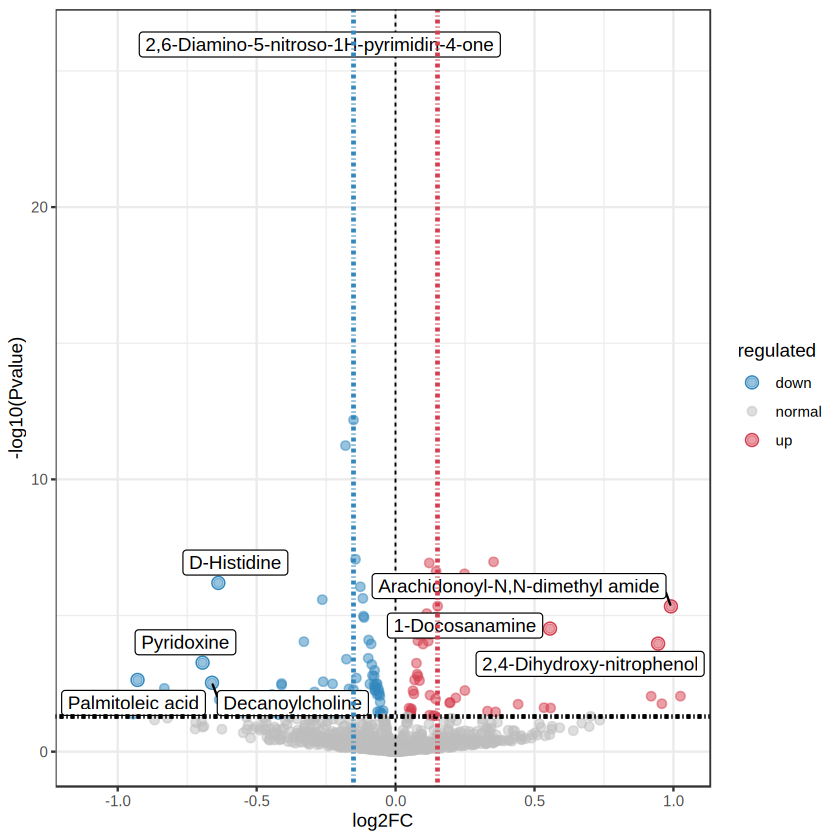

In [136]:
p2 <- p1+geom_hline(yintercept = -log10(0.05),lty=4,col="black",lwd=1)+
  geom_vline(xintercept = c(0.15), lty=4,col="#D53E4F",lwd=1)+geom_vline(xintercept = c(-0.15), lty=4,col="#3288BD",lwd=1)
p2

In [137]:
ggsave("DEG_Volcano_plot_top10_meta_TR_R_base_edgR.pdf",p2,width = 7,height = 6)
ggsave("DEG_Volcano_plot_top10_meta_TR_R_base_edgR.png",p2,width = 7,height = 6)